# 3 · Rate capability and a full cycle

Discharges at several C-rates, and then a cycling protocol (docs/protocol.md) with constant-current and constant-voltage steps. These are illustrative default parameters, not fitted to a cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lfp_model.params import Params
from lfp_model.simulate import run

to_mAhg = lambda p, eq: eq * p.F / (p.M * 3.6)

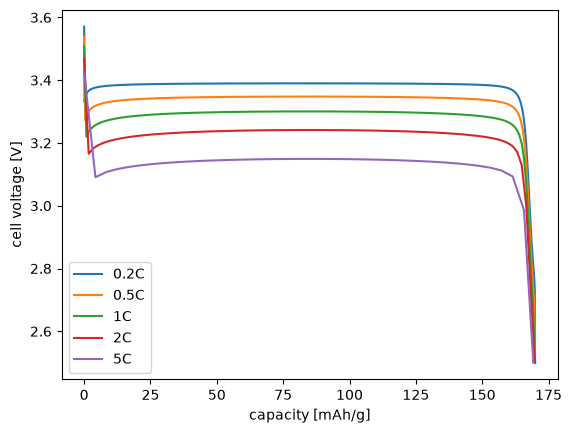

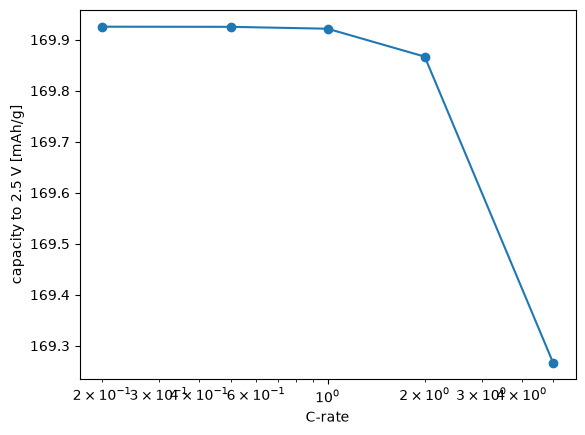

In [2]:
rates = [0.2, 0.5, 1.0, 2.0, 5.0]
caps = []
for cr in rates:
    p = Params(mode="corrected", C_rate=cr)
    a = run(p).array
    plt.plot(to_mAhg(p, a[:, 2]), a[:, 1], label=f"{cr:g}C")
    caps.append(to_mAhg(p, a[-1, 2]))
plt.xlabel("capacity [mAh/g]"); plt.ylabel("cell voltage [V]"); plt.legend(); plt.show()

plt.semilogx(rates, caps, "o-")
plt.xlabel("C-rate"); plt.ylabel("capacity to 2.5 V [mAh/g]"); plt.show()

## A full cycle

Discharge at 1C to 2.5 V, rest, charge at 1C to 4.0 V, hold 4.0 V until the current falls below C/20, then rest. The same protocol string works in the Fortran and C++ programs (`&protocol steps = '...'`).

end_of_protocol


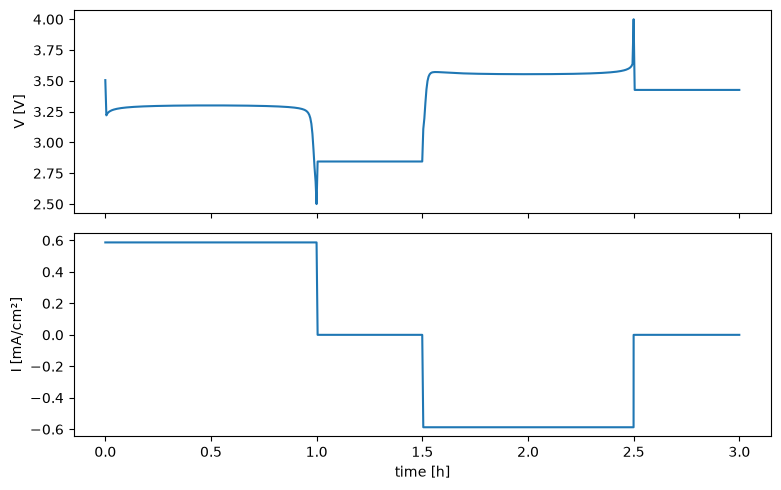

In [3]:
steps = "cc C=1 Vmin=2.5; rest t=1800; cc C=-1 Vmax=4.0; cv V=4.0 Imin=0.05; rest t=1800"
p = Params(mode="corrected", steps=steps)
r = run(p)
a = r.array
print(r.exit_reason)
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(a[:, 0], a[:, 1]); ax[0].set_ylabel("V [V]")
ax[1].plot(a[:, 0], a[:, 6]); ax[1].set_ylabel("I [mA/cm²]"); ax[1].set_xlabel("time [h]")
plt.tight_layout(); plt.show()